In [208]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [209]:
import torch
from torch import nn, optim
# di sini kita akan masuk ke callback
from jcopdl.callback import Callback, set_config


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

# Import Data

In [210]:
df = pd.read_csv(r"D:\Belajar ML dan AI\deep_learning-master\16 - Recurrent Neural Network\data\daily_min_temp.csv", parse_dates=["Date"],index_col="Date")
df.head()

,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


<Axes: xlabel='Date'>

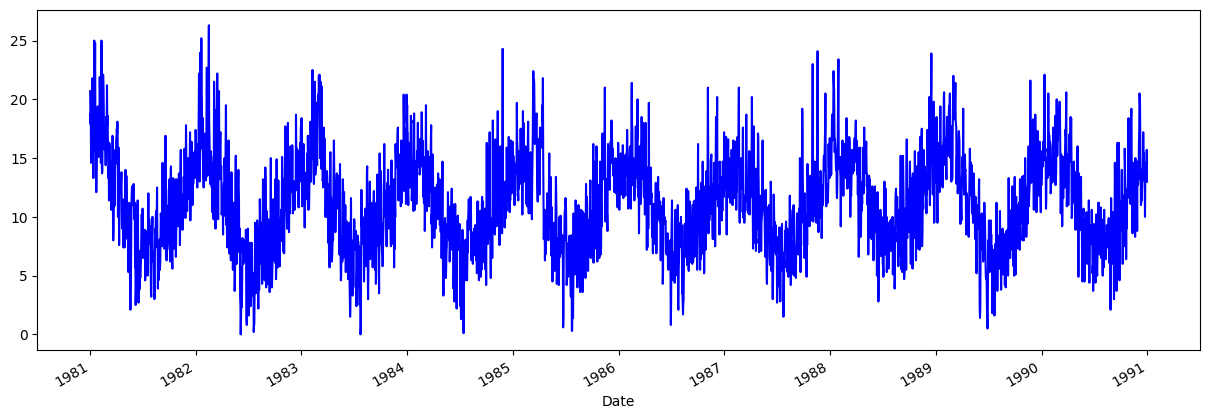

In [211]:
df.Temp.plot(figsize=(15,5), color="b")

In [212]:
df.head()

,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


In [213]:
df

,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8
...,...
1990-12-27,14.0
1990-12-28,13.6
1990-12-29,13.5


# Daset Spliting

In [214]:
ts_train, ts_test = train_test_split(df, test_size=0.2,shuffle=False,)
ts_train.shape, ts_test.shape

((2920, 1), (730, 1))

# Daset dan Dataloader

In [215]:
from torch.utils.data import  DataLoader


1. Yang ini Versi coustom datasetnya

In [216]:
import torch
from torch.utils.data import Dataset  # Pastikan baris ini ada

class MyTimeSeriesDataset(Dataset):
    def __init__(self, data, target_cols, seq_len):
        self.columns = data.columns.tolist()
        
        # --- Tambahkan ini ---
        # Mengambil indeks dari DataFrame (misal: tanggal/waktu) 
        # mulai dari data ke-seq_len hingga akhir
        self.target_ticks = data.index[seq_len:]
        # ---------------------
        
        if isinstance(target_cols, str):
            target_cols = [target_cols]
            
        for col in target_cols:
            if col not in self.columns:
                raise ValueError(f"Kolom '{col}' tidak ditemukan.")
        
        self.target_indices = [self.columns.index(col) for col in target_cols]
        self.data = torch.tensor(data.values, dtype=torch.float32)
        self.seq_len = seq_len
        self.num_targets = len(target_cols)

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_len]
        y = self.data[idx + self.seq_len, self.target_indices]
        return x, y.view(-1) 

    def __repr__(self):
        return f"TimeSeriesDataset(Total Data={len(self.data)}, SeqLen={self.seq_len}, TargetCols={self.num_targets})"

In [217]:
seq_len = 16
bs = 32

train_set = MyTimeSeriesDataset(ts_train, "Temp", seq_len)
trainloader = DataLoader(train_set, batch_size=bs, shuffle=True)  

test_set = MyTimeSeriesDataset(ts_test, "Temp", seq_len)
testloader= DataLoader(test_set, batch_size=bs, shuffle=False)  

# Arsitektur dan config

In [218]:
from jcopdl.layers import linear_block

In [219]:
class GRU(nn.Module):
    def __init__(self, input_size, output_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.rnn = nn.GRU(input_size, hidden_size, num_layers, dropout=dropout, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x, hidden):
        x, hidden = self.rnn(x, hidden)
        x = self.fc(x[:, -1, :])   # hanya timestep terakhir → [batch, output_size]
        return x, hidden

Jadi Bedanya adalah :
1. Ganti nama fungsi nya dengan LSTM
2. Pytorch sudah menyediakan LSTM block nya 

In [220]:
from types import SimpleNamespace

def set_config(params):
    return SimpleNamespace(**params)

# Penggunaan:
config = set_config({
    "input_size": train_set.data.shape[1],
    "output_size": train_set.num_targets,
    "hidden_size": 129,        # Ditingkatkan untuk kapasitas memori model
    "num_layers": 2,           # Menjaga kedalaman agar tidak terlalu kompleks
    "dropout": 0.2,            # Regularisasi untuk mencegah overfitting
   # Menambah efektivitas dalam menangkap konteks temporal
    "seq_len": train_set.seq_len
})

# MCOC

In [221]:
model = GRU(config.input_size, config.output_size,config.hidden_size,config.num_layers, config.dropout).to(device)
criterion = nn.MSELoss(reduction="mean")
optimizer = optim.AdamW(model.parameters(), lr=0.001)
callback = Callback(model, config, outdir="model/LSTM")

# Training

In [222]:
from tqdm.auto import tqdm

def loop_fn(mode, dataset, dataloader, model, criterion, optimizer, device):
    if mode == "train":
        model.train()
    elif mode == "test":
        model.eval()
    cost = 0
    for feature, target in tqdm(dataloader, desc=mode.title()):
        feature, target = feature.to(device), target.to(device)
        # BEDANYA CUMAN DI SINI DOANG NN DENGAM RNN
        output, hidden = model(feature, None)
        loss = criterion(output, target)
        
        if mode == "train":
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        
        cost += loss.item() * feature.shape[0]
    cost = cost / len(dataset)
    return cost

Train:   0%|          | 0/91 [00:00<?, ?it/s]

Test:   0%|          | 0/23 [00:00<?, ?it/s]


Epoch     1
Train_cost  = 27.1906 | Test_cost  = 16.8439 | 


Train:   0%|          | 0/91 [00:00<?, ?it/s]

Test:   0%|          | 0/23 [00:00<?, ?it/s]

...

Test:   0%|          | 0/23 [00:00<?, ?it/s]


Epoch    19
Train_cost  = 6.0043 | Test_cost  = 4.8085 | 
==> EarlyStop patience =  4 | Best test_cost: 4.7995


Train:   0%|          | 0/91 [00:00<?, ?it/s]

Test:   0%|          | 0/23 [00:00<?, ?it/s]


Epoch    20
Train_cost  = 5.9927 | Test_cost  = 4.7965 | 


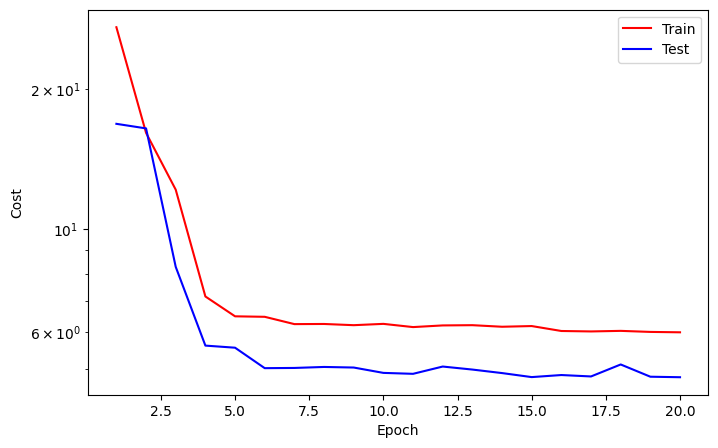

Train:   0%|          | 0/91 [00:00<?, ?it/s]

Test:   0%|          | 0/23 [00:00<?, ?it/s]


Epoch    21
Train_cost  = 6.0552 | Test_cost  = 4.8702 | 
==> EarlyStop patience =  1 | Best test_cost: 4.7965


Train:   0%|          | 0/91 [00:00<?, ?it/s]

Test:   0%|          | 0/23 [00:00<?, ?it/s]

...


Epoch    34
Train_cost  = 5.8716 | Test_cost  = 5.0505 | 
==> EarlyStop patience =  4 | Best test_cost: 4.7586


Train:   0%|          | 0/91 [00:00<?, ?it/s]

Test:   0%|          | 0/23 [00:00<?, ?it/s]


Epoch    35
Train_cost  = 5.8271 | Test_cost  = 4.8309 | 
==> EarlyStop patience =  5 | Best test_cost: 4.7586
==> Execute Early Stopping at epoch: 35 | Best test_cost: 4.7586
==> Best model is saved at model/LSTM


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\jcopdl\callback\_callback.py:104: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights = torch.load(

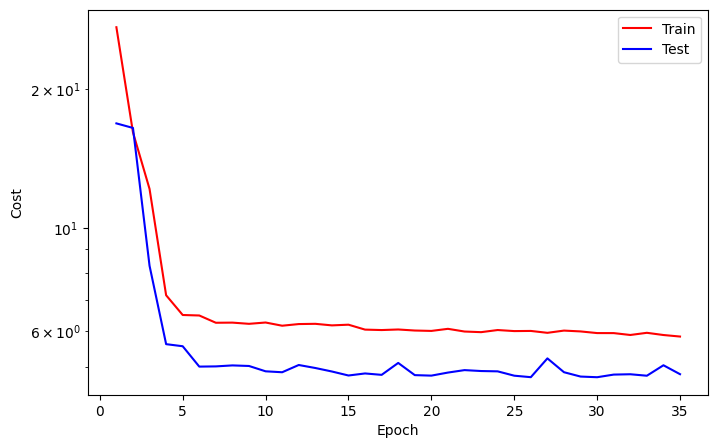

In [223]:
while True:
    train_cost = loop_fn("train", train_set, trainloader, model, criterion, optimizer, device)
    with torch.no_grad():
        test_cost = loop_fn("test", test_set, testloader, model, criterion, optimizer, device)
    
    # Logging
    callback.log(train_cost, test_cost)

    # Checkpoint
    callback.save_checkpoint()
        
    # Runtime Plotting
    callback.cost_runtime_plotting()
    
    # Early Stopping
    if callback.early_stopping(model, monitor="test_cost"):
        callback.plot_cost()
        break


# FORCESTING


In [224]:
from utils import data4pred, pred4pred

In [225]:
train_forcest = MyTimeSeriesDataset(ts_train,"Temp", 1)
trainforcestloader = DataLoader(train_forcest)

test_forcest = MyTimeSeriesDataset(ts_test,"Temp",1)
testdorcestloader = DataLoader(test_forcest)


Text(0.5, 1.0, 'Test')

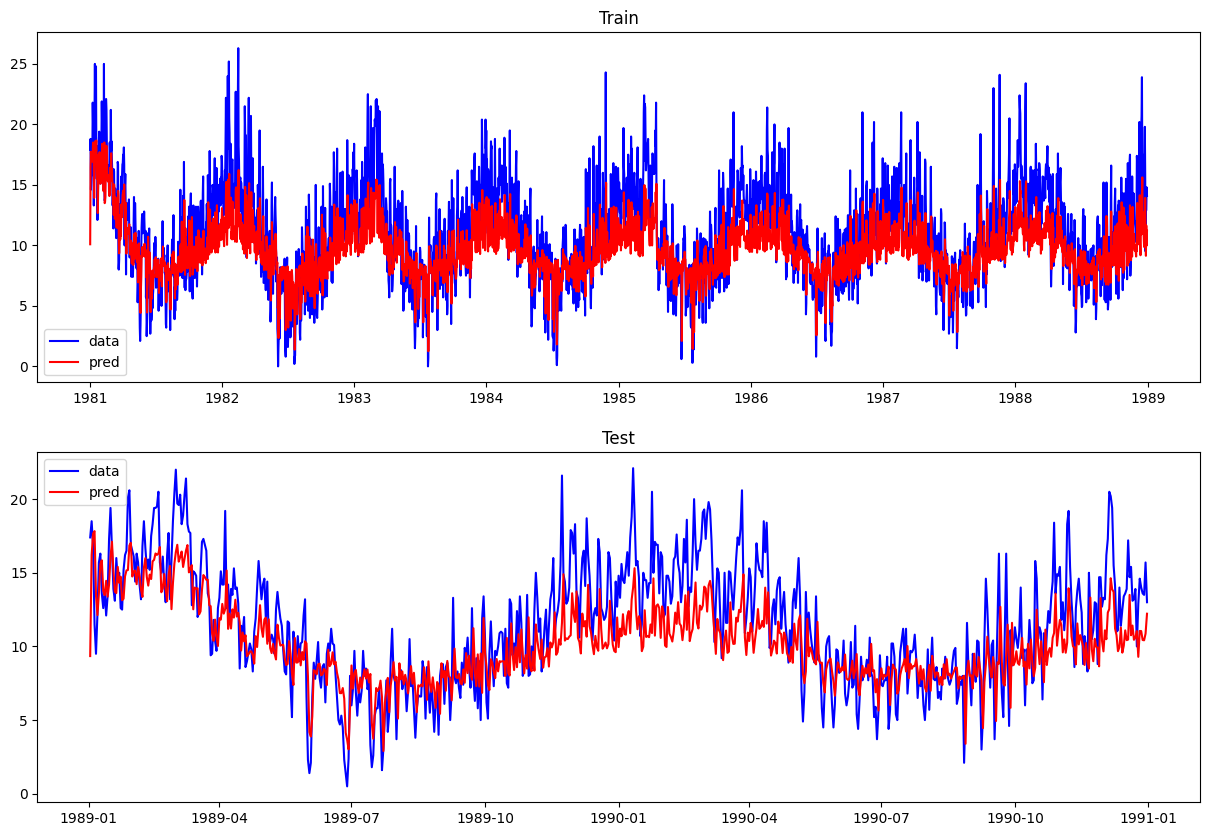

In [226]:
plt.figure(figsize=(15, 10))

plt.subplot(211)
data4pred(model, train_forcest, trainforcestloader, device)
plt.title("Train")

plt.subplot(212)
data4pred(model,test_forcest, testdorcestloader, device)
plt.title("Test")

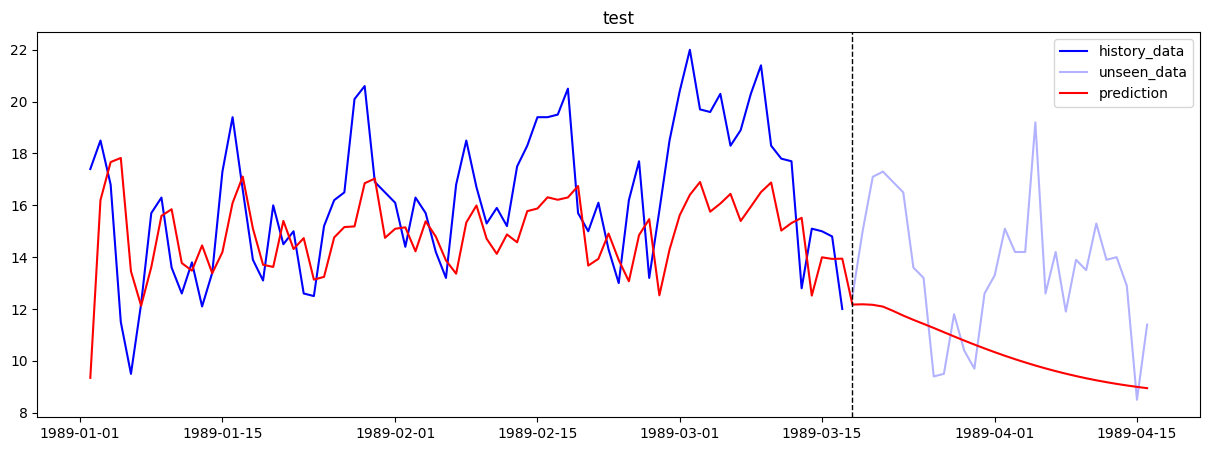

In [227]:
plt.figure(figsize=(15, 5))
pred4pred(model, test_forcest, testdorcestloader , device)
plt.title("test");


Jadi Kesimpulannya sudah bener sequns_leng nya di uabh ke 16 itu bekerja , karena informasinya cukup jadi sebenarnya ml itu dia hanya mencari pola , tugas kita adalah seberapa banyak informasi yang masuk akal yang fitur nya bermakna supya machine lebih bagus

# Coba yang menarik kita akan forcest unutk memprediksi semuanya 

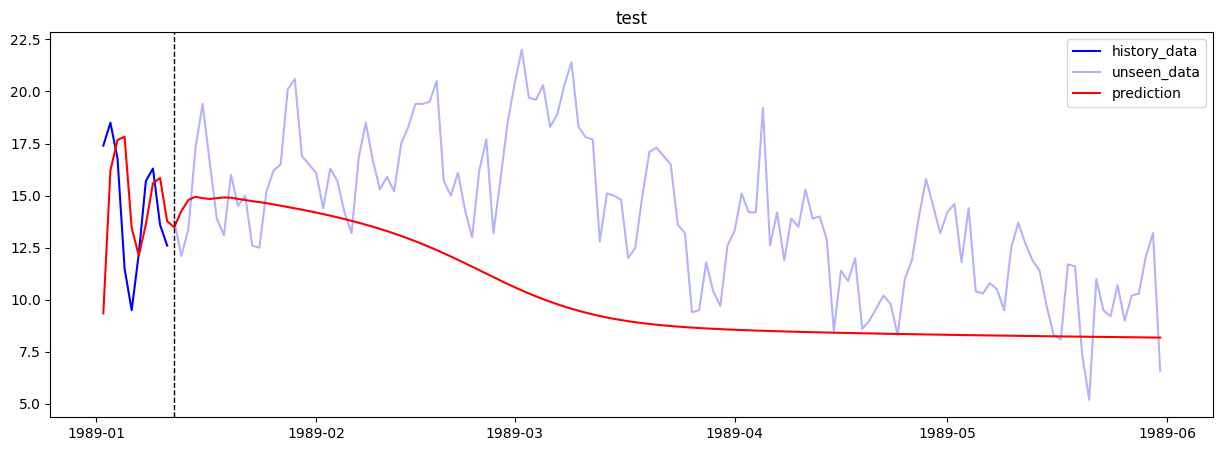

In [228]:
# n_prior kita akan mengambil konteks 10 data di awal 
# n_forcest model akan mencoba memprediksi 140 langkah waktu ke depan setelah titik akhir dari n_prior
plt.figure(figsize=(15, 5))
pred4pred(model, test_forcest, testdorcestloader , device, n_prior=10, n_forecast=140)
plt.title("test");


Nah walaupun kita sudah kasih rnn sequend_leng nya sudah makesence pun semakin jauh prediksi kita di masa depan itu semakin meleset, jg merasa bersalah prediksi nya meleset karena prediksi semakin jauh ke masa depan itu semakin tinggi ketidak pastian nya 

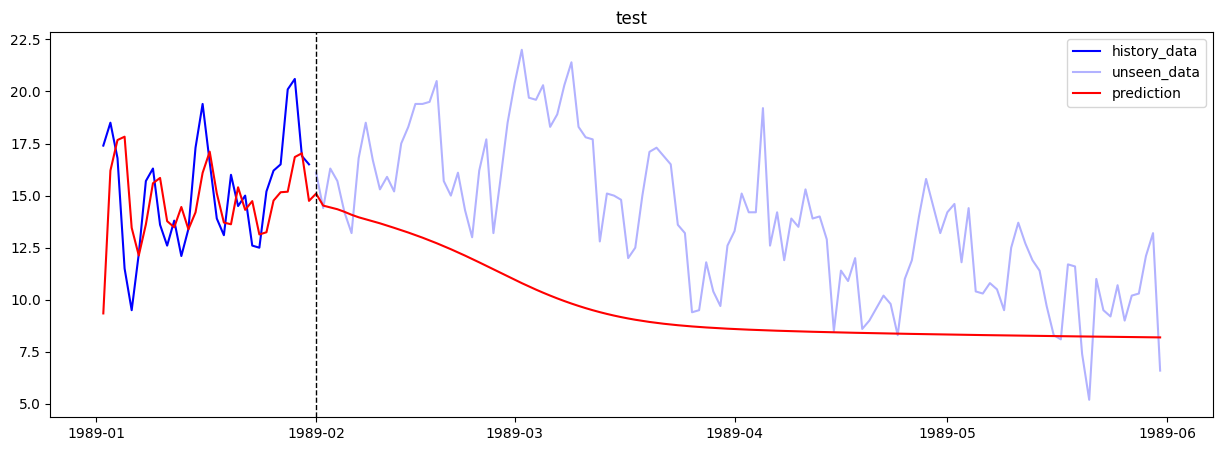

In [229]:
# mungkin konteks kita di atas kurang kalau cuman 10 
# maka unutk konteks nya akan kita naikan ke 30
plt.figure(figsize=(15, 5))
pred4pred(model, test_forcest, testdorcestloader , device, n_prior=30, n_forecast=120)
plt.title("test");

Hal yang menarik di time series forcesting bydefault itu oferfit kita harus harap prediksi kita salah jadi jangan khawatir kalau salah , kalau kita bisa jamin prediksi akurat maka gak akan ada masalah lagi di dunia ini